In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv("Dataco (Abhijit database)_Dataco.csv")

In [5]:
df.head()

,Additional Order items,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Segment,Customer State,Customer Zipcode,Market,Order Customer Id,Order Date,Order Id,Order Region,Order Item Total,Order Quantity,Product Price,Profit Margin,Profit Per Order,Sales
0,Camping & Hiking,Camping & Hiking,Caguas,Puerto Rico,Sean,568,Consumer,PR,725.0,LATAM,568,17-06-2017,61558,South America,269.980011,1,299.980011,26.10%,78.290001,800.000000
1,Camping & Hiking,Camping & Hiking,Caguas,Puerto Rico,Carol,3341,Consumer,PR,725.0,LATAM,3341,18-04-2017,57472,South America,269.980011,1,299.980011,-5.40%,-16.200001,800.000000
2,Camping & Hiking,Camping & Hiking,Mayaguez,Puerto Rico,Mary,7459,Consumer,PR,680.0,LATAM,7459,24-05-2017,59898,Central America,263.980011,1,299.980011,3.90%,11.620000,800.000000
3,Camping & Hiking,Camping & Hiking,Mayaguez,Puerto Rico,Mary,7459,Consumer,PR,680.0,LATAM,7459,24-05-2017,59898,Central America,260.980011,1,299.980011,-1.10%,-3.390000,800.000000
4,Hunting & Shooting,Hunting & Shooting,Caguas,Puerto Rico,Mary,10740,Consumer,PR,725.0,LATAM,10740,05-06-2017,58644,Central America,130.490005,1,149.990005,-63.80%,-95.650002,149.990005


In [6]:
df.shape

(115746, 20)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115746 entries, 0 to 115745
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Additional Order items  114722 non-null  str    
 1   Category Name           115746 non-null  str    
 2   Customer City           115746 non-null  str    
 3   Customer Country        115746 non-null  str    
 4   Customer Fname          115746 non-null  str    
 5   Customer Id             115746 non-null  int64  
 6   Customer Segment        115746 non-null  str    
 7   Customer State          115746 non-null  str    
 8   Customer Zipcode        115743 non-null  float64
 9   Market                  115746 non-null  str    
 10  Order Customer Id       115746 non-null  int64  
 11  Order Date              115746 non-null  str    
 12  Order Id                115746 non-null  int64  
 13  Order Region            115746 non-null  str    
 14  Order Item Total        115746 

In [8]:
df.describe()

,Customer Id,Customer Zipcode,Order Customer Id,Order Id,Order Item Total,Order Quantity,Product Price,Profit Per Order,Sales
count,115746.000000,115743.000000,115746.000000,115746.000000,115746.000000,115746.000000,115746.000000,115746.000000,115746.000000
mean,6714.510506,36031.651158,6714.510506,48314.658243,187.193568,2.551535,146.499821,22.585698,237.959730
std,4096.926311,37585.060790,4096.926311,13532.737160,128.775391,1.683874,150.401535,108.636460,194.407483
min,2.000000,603.000000,2.000000,25005.000000,7.490000,1.000000,9.990000,-4274.979980,9.990000
25%,3291.000000,725.000000,3291.000000,36696.000000,106.589996,1.000000,50.000000,7.200000,129.990005
50%,6507.000000,19380.000000,6507.000000,48195.000000,165.990005,2.000000,99.989998,32.040001,199.949997
75%,9874.000000,78223.000000,9874.000000,59728.000000,248.979996,4.000000,199.990005,65.727503,299.980011
max,18634.000000,99205.000000,18634.000000,75081.000000,1939.989990,5.000000,1999.989990,911.799988,1999.989990


In [9]:
df.isnull().sum()

Additional Order items    1024
Category Name                0
Customer City                0
Customer Country             0
Customer Fname               0
Customer Id                  0
Customer Segment             0
Customer State               0
Customer Zipcode             3
Market                       0
Order Customer Id            0
Order Date                   0
Order Id                     0
Order Region                 0
Order Item Total             0
Order Quantity               0
Product Price                0
Profit Margin                0
Profit Per Order             0
Sales                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True,
    errors="coerce"
)

In [12]:
df["Profit Margin"] = (
    df["Profit Margin"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["Profit Margin"] = pd.to_numeric(
    df["Profit Margin"],
    errors="coerce"
)

In [13]:
numeric_cols = [
    "Order Item Total",
    "Order Quantity",
    "Product Price",
    "Profit Per Order",
    "Sales"
]

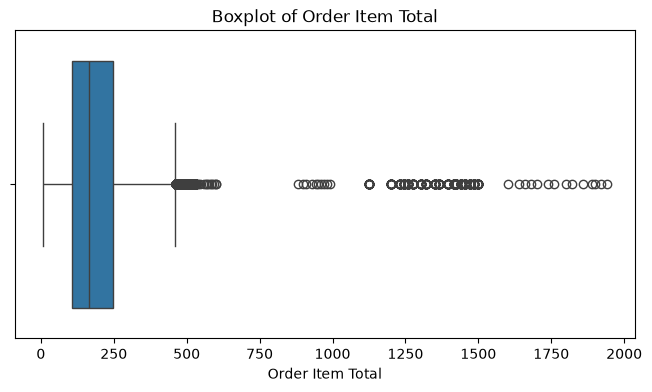

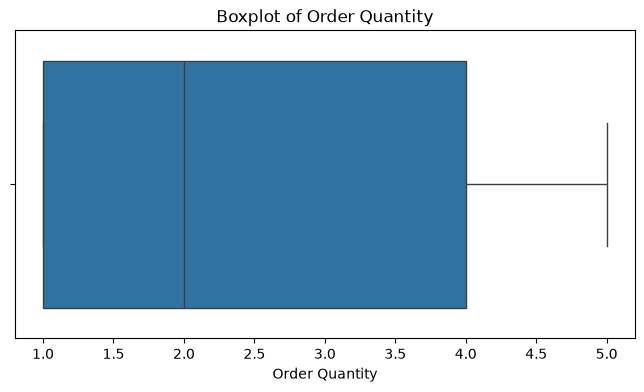

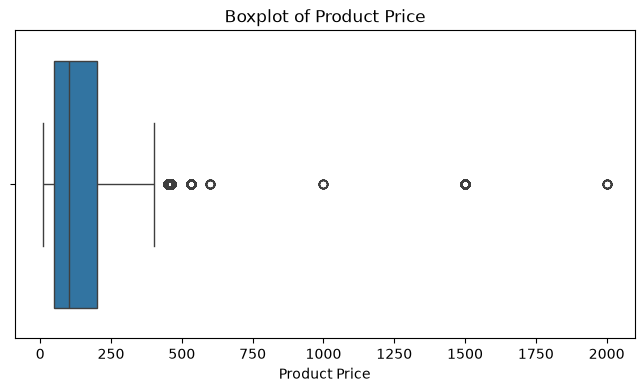

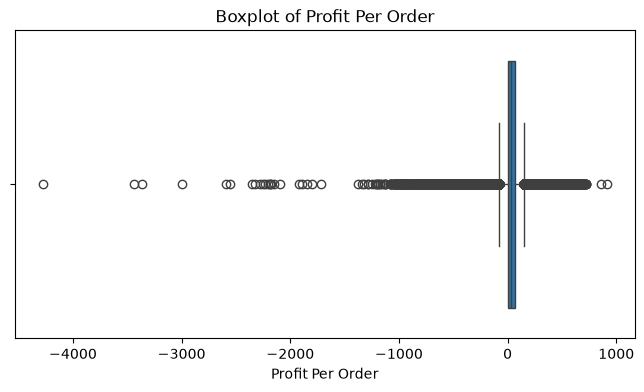

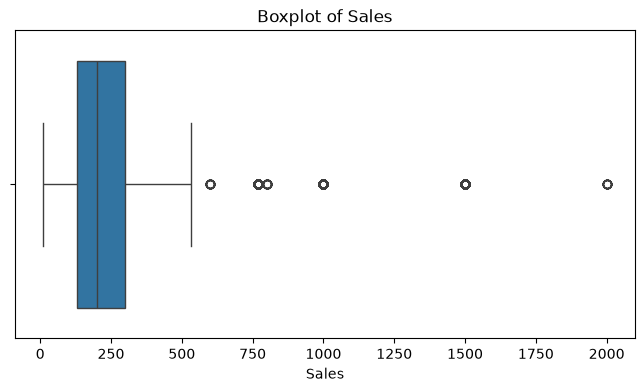

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
analysis_date = df["Order Date"].max()
analysis_date

Timestamp('2017-12-31 00:00:00')

In [16]:
customer_df = df.groupby("Customer Id").agg(
    Recency=("Order Date", lambda x: (analysis_date - x.max()).days),
    Frequency=("Order Id", "nunique"),
    Monetary=("Sales", "sum"),
    Avg_Order_Value=("Sales", "mean"),
    Avg_Quantity=("Order Quantity", "mean"),
    Avg_Profit=("Profit Per Order", "mean")
).reset_index()

In [18]:
customer_df["Churn"] = (
    customer_df["Recency"] > 90
).astype(int)

In [19]:
customer_df["Churn"].value_counts()

Churn
1    12156
0     5850
Name: count, dtype: int64

In [20]:
customer_df["Churn"].value_counts(normalize=True) * 100

Churn
1    67.51083
0    32.48917
Name: proportion, dtype: float64

In [21]:
X = customer_df[
    [
        "Frequency",
        "Monetary",
        "Avg_Order_Value",
        "Avg_Quantity",
        "Avg_Profit"
    ]
]

In [22]:
y = customer_df["Churn"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
numeric_features = [
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Avg_Quantity",
    "Avg_Profit"
]

In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [26]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [27]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
categorical_features = [
    "Customer Segment"
]

In [29]:
segment_df = df.groupby("Customer Id")["Customer Segment"].first()

customer_df = customer_df.merge(
    segment_df,
    on="Customer Id",
    how="left"
)

In [30]:
categorical_features = [
    "Customer Segment"
]

In [31]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [32]:
strategy="most_frequent"

In [33]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [34]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [35]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [36]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10
    ))
])

In [40]:
print("X columns:")
print(X.columns.tolist())

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nX_train columns:")
print(X_train.columns.tolist())

X columns:
['Frequency', 'Monetary', 'Avg_Order_Value', 'Avg_Quantity', 'Avg_Profit']

Numeric features:
['Frequency', 'Monetary', 'Avg_Order_Value', 'Avg_Quantity', 'Avg_Profit']

Categorical features:
['Customer Segment']

X_train columns:
['Frequency', 'Monetary', 'Avg_Order_Value', 'Avg_Quantity', 'Avg_Profit']


In [41]:
categorical_features = ["Customer Segment"]

In [42]:
numeric_features = [
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Avg_Quantity",
    "Avg_Profit"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [43]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features)
])

In [44]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [45]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [46]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10
    ))
])

In [47]:
logistic_pipeline.fit(X_train, y_train)

tree_pipeline.fit(X_train, y_train)

forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Frequency','Monetary','Avg_Order_Value','Avg_Quantity','Avg_Profit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining col

In [48]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_pred_tree = tree_pipeline.predict(X_test)

y_pred_forest = forest_pipeline.predict(X_test)

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_logistic, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_logistic, zero_division=0))


print("\n===== Decision Tree =====")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_tree, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_tree, zero_division=0))


print("\n===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_forest))
print("Precision:", precision_score(y_test, y_pred_forest, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_forest, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_forest, zero_division=0))

===== Logistic Regression =====
Accuracy : 0.784564131038312
Precision: 0.7799188640973631
Recall   : 0.9486019736842105
F1 Score : 0.8560296846011132

===== Decision Tree =====
Accuracy : 0.8573014991671294
Precision: 0.8677147239263804
Recall   : 0.9305098684210527
F1 Score : 0.898015873015873

===== Random Forest =====
Accuracy : 0.859800111049417
Precision: 0.8692985818321196
Recall   : 0.9325657894736842
F1 Score : 0.899821463995239


In [50]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Frequency','Monetary','Avg_Order_Value','Avg_Quantity','Avg_Profit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining col

In [51]:
def evaluate_model(name, model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [52]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_pipeline,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        tree_pipeline,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        forest_pipeline,
        X_test,
        y_test
    )
)

In [53]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.784564,0.779919,0.948602,0.856030
1,Decision Tree,0.857301,0.867715,0.930510,0.898016
2,Random Forest,0.859800,0.869299,0.932566,0.899821


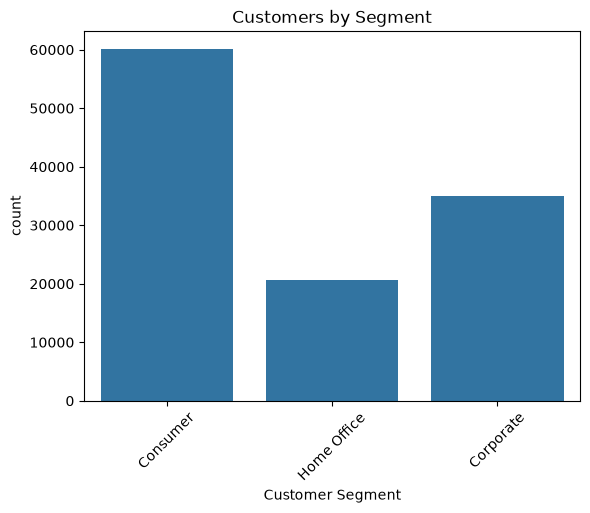

In [54]:
sns.countplot(data=df, x="Customer Segment")

plt.title("Customers by Segment")
plt.xticks(rotation=45)
plt.show()

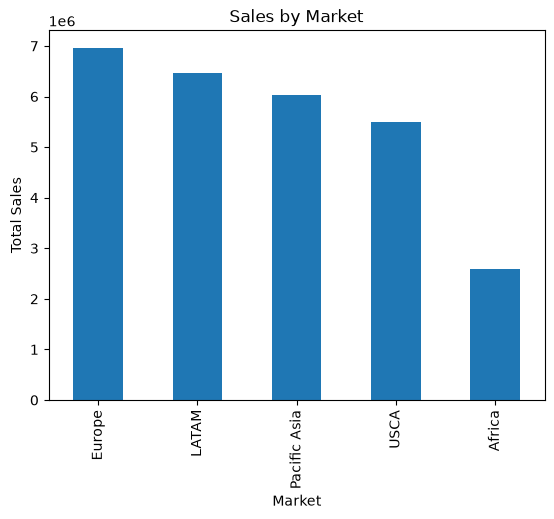

In [55]:
market_sales = df.groupby("Market")["Sales"].sum().sort_values(ascending=False)

market_sales.plot(kind="bar")

plt.title("Sales by Market")
plt.ylabel("Total Sales")
plt.show()

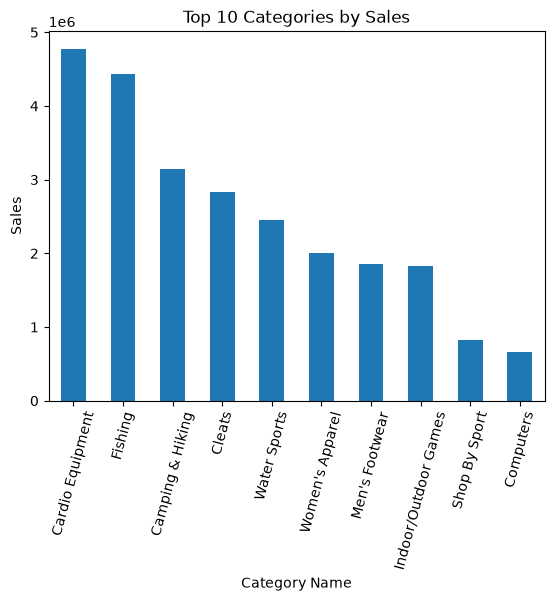

In [56]:
category_sales = (
    df.groupby("Category Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_sales.plot(kind="bar")

plt.title("Top 10 Categories by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.show()

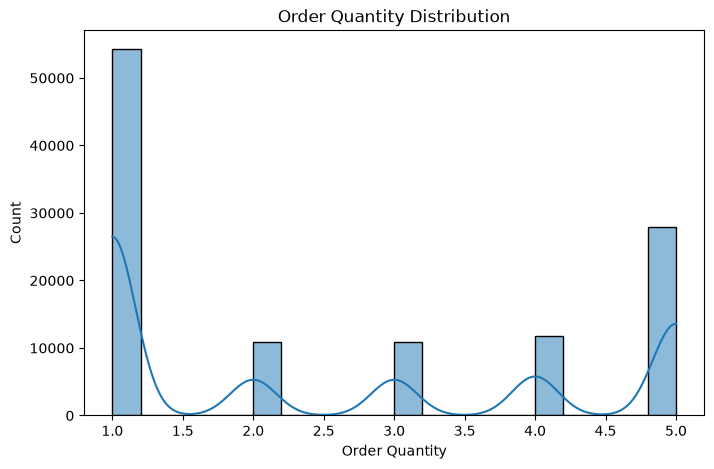

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Order Quantity",
    bins=20,
    kde=True
)

plt.title("Order Quantity Distribution")
plt.show()

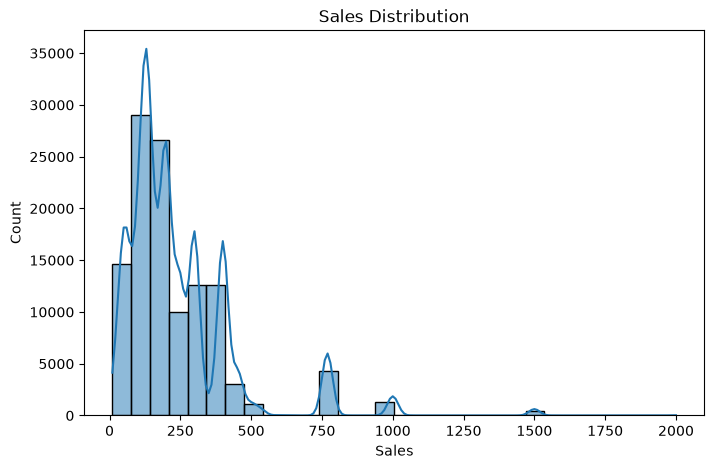

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.show()

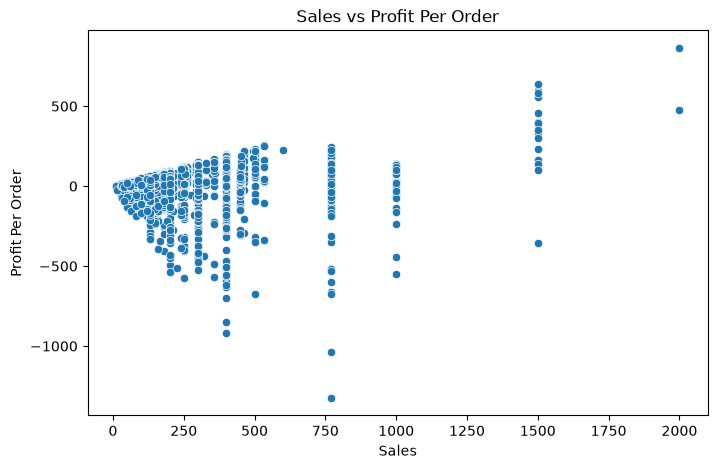

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="Sales",
    y="Profit Per Order"
)

plt.title("Sales vs Profit Per Order")
plt.show()

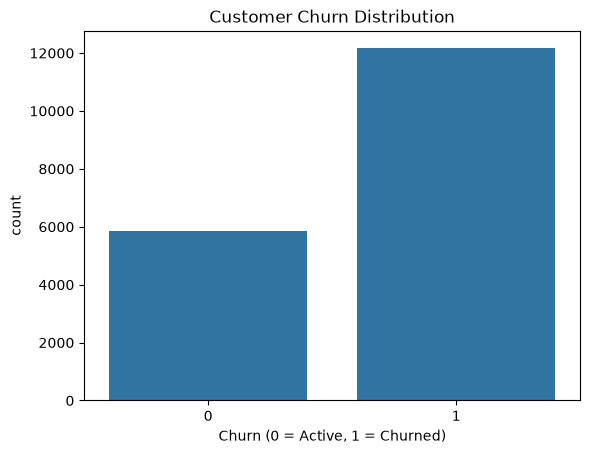

In [60]:
sns.countplot(data=customer_df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.show()

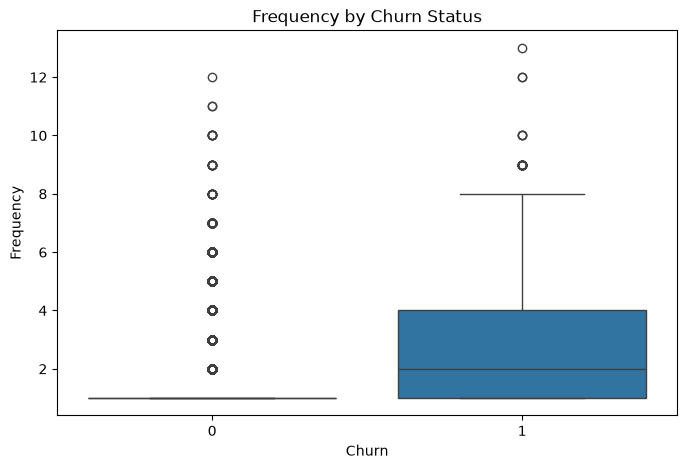

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=customer_df,
    x="Churn",
    y="Frequency"
)

plt.title("Frequency by Churn Status")
plt.show()

In [62]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    forest_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("CV F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV F1 Scores: [0.80570292 0.95279308 0.88539572 0.85317878 0.52552639]
Mean CV F1: 0.8045193786742122


In [63]:
cv_scores.mean()

np.float64(0.8045193786742122)